In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv("../data/final_modeling_dataset.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (997, 15)


,PTID,MCI_DATE,AD_CONVERSION_2YR,AGE,PTGENDER,PTEDUCAT,PTETHCAT,PTRACCAT,APOE,CDGLOBAL,CDRSB,MMSCORE,LEFT_HIPPOCAMPUS_VOLUME,RIGHT_HIPPOCAMPUS_VOLUME,APOE_E4_CARRIER
0,002_S_0729,2006-08-03,1,65.2,Female,16.0,Not Hispanic or Latino,White,ε3/ε4,0.5,0.5,27.0,3172.8,3063.2,1.0
1,002_S_0782,2006-08-23,0,81.6,Male,16.0,Not Hispanic or Latino,White,ε3/ε3,0.5,0.5,29.0,2985.5,3735.7,0.0
2,002_S_0954,2006-11-22,1,69.4,Female,14.0,Not Hispanic or Latino,White,ε3/ε4,0.5,2.0,25.0,2599.6,2866.9,1.0
3,002_S_1070,2006-12-27,1,73.7,Male,14.0,Not Hispanic or Latino,White,ε3/ε3,0.5,2.5,25.0,4842.4,4664.6,0.0
4,002_S_1155,2007-01-10,0,57.9,Male,20.0,Not Hispanic or Latino,White,ε3/ε3,0.5,1.5,28.0,4058.5,4208.8,0.0


In [3]:
target = "AD_CONVERSION_2YR"

primary_features = [
    "AGE",
    "PTGENDER",
    "PTEDUCAT",
    "PTETHCAT",
    "PTRACCAT",
    "APOE",
    "CDGLOBAL",
    "CDRSB",
    "MMSCORE"
]

X = df[primary_features].copy()
y = df[target].copy()

print("Features:", primary_features)
print("Number of features:", len(primary_features))
print("Target:", target)
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features: ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'APOE', 'CDGLOBAL', 'CDRSB', 'MMSCORE']
Number of features: 9
Target: AD_CONVERSION_2YR

X shape: (997, 9)
y shape: (997,)

Target distribution:
AD_CONVERSION_2YR
0    878
1    119
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (797, 9)
Test set: (200, 9)

Training target distribution:
AD_CONVERSION_2YR
0    702
1     95
Name: count, dtype: int64

Test target distribution:
AD_CONVERSION_2YR
0    176
1     24
Name: count, dtype: int64


In [5]:
numeric_features = [
    "AGE",
    "PTEDUCAT",
    "CDGLOBAL",
    "CDRSB",
    "MMSCORE"
]

categorical_features = [
    "PTGENDER",
    "PTETHCAT",
    "PTRACCAT",
    "APOE"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline defined successfully.")

Preprocessing pipeline defined successfully.


In [6]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Test data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (797, 22)
Test data after preprocessing: (200, 22)


In [7]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Predicted class
y_pred = xgb_model.predict(X_test_processed)

# Predicted probability for the converter class
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

print("XGBoost Performance")
print("-------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall (Sensitivity):", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

XGBoost Performance
-------------------
Accuracy: 0.78
Balanced Accuracy: 0.6410984848484849
Precision: 0.2619047619047619
Recall (Sensitivity): 0.4583333333333333
F1 Score: 0.3333333333333333
ROC-AUC: 0.6922348484848485
PR-AUC: 0.2458613127830364

Confusion Matrix:
[[145  31]
 [ 13  11]]


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [10]:
# Predicted class
rf_pred = rf_model.predict(X_test_processed)

# Predicted probability for the converter class
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest Performance")
print("------------------------")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall (Sensitivity):", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("PR-AUC:", average_precision_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Performance
------------------------
Accuracy: 0.78
Balanced Accuracy: 0.6590909090909092
Precision: 0.2727272727272727
Recall (Sensitivity): 0.5
F1 Score: 0.35294117647058826
ROC-AUC: 0.7402935606060607
PR-AUC: 0.2899431326445321

Confusion Matrix:
[[144  32]
 [ 12  12]]


In [11]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm_model = ExplainableBoostingClassifier(
    interactions=0,
    random_state=42
)

ebm_model.fit(X_train_processed, y_train)

print("EBM model trained successfully.")

EBM model trained successfully.


In [12]:
# Predicted class
ebm_pred = ebm_model.predict(X_test_processed)

# Predicted probability for the converter class
ebm_prob = ebm_model.predict_proba(X_test_processed)[:, 1]

print("EBM Performance")
print("----------------")
print("Accuracy:", accuracy_score(y_test, ebm_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, ebm_pred))
print("Precision:", precision_score(y_test, ebm_pred))
print("Recall (Sensitivity):", recall_score(y_test, ebm_pred))
print("F1 Score:", f1_score(y_test, ebm_pred))
print("ROC-AUC:", roc_auc_score(y_test, ebm_prob))
print("PR-AUC:", average_precision_score(y_test, ebm_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, ebm_pred))

EBM Performance
----------------
Accuracy: 0.88
Balanced Accuracy: 0.5
Precision: 0.0
Recall (Sensitivity): 0.0
F1 Score: 0.0
ROC-AUC: 0.7561553030303031
PR-AUC: 0.32798377413601687

Confusion Matrix:
[[176   0]
 [ 24   0]]


c:\Users\anura\.conda\envs\mci_ad_xai\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
results = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest", "EBM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ebm_pred)
    ],
    "Balanced_Accuracy": [
        balanced_accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, rf_pred),
        balanced_accuracy_score(y_test, ebm_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0),
        precision_score(y_test, ebm_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, ebm_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, ebm_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, ebm_prob)
    ],
    "PR_AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, ebm_prob)
    ]
})

results

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,XGBoost,0.78,0.641098,0.261905,0.458333,0.333333,0.692235,0.245861
1,Random Forest,0.78,0.659091,0.272727,0.500000,0.352941,0.740294,0.289943
2,EBM,0.88,0.500000,0.000000,0.000000,0.000000,0.756155,0.327984


In [14]:
results.to_csv("../results/baseline_model_performance.csv", index=False)

print("Baseline model performance saved successfully.")

Baseline model performance saved successfully.


In [15]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
for i, name in enumerate(feature_names):
    print(i, name)
    

Number of processed features: 22

Processed feature names:
0 num__AGE
1 num__PTEDUCAT
2 num__CDGLOBAL
3 num__CDRSB
4 num__MMSCORE
5 cat__PTGENDER_Female
6 cat__PTGENDER_Male
7 cat__PTETHCAT_Hispanic or Latino
8 cat__PTETHCAT_Not Hispanic or Latino
9 cat__PTETHCAT_Unknown
10 cat__PTRACCAT_American Indian or Alaskan Native
11 cat__PTRACCAT_Asian
12 cat__PTRACCAT_Black or African American
13 cat__PTRACCAT_More than one race
14 cat__PTRACCAT_Native Hawaiian or Other Pacific Islander
15 cat__PTRACCAT_Unknown
16 cat__PTRACCAT_White
17 cat__APOE_ε2/ε3
18 cat__APOE_ε2/ε4
19 cat__APOE_ε3/ε3
20 cat__APOE_ε3/ε4
21 cat__APOE_ε4/ε4


In [16]:
import shap

xgb_explainer = shap.TreeExplainer(xgb_model)

xgb_shap_values = xgb_explainer.shap_values(X_test_processed)

print("SHAP values calculated successfully.")
print("SHAP shape:", xgb_shap_values.shape)

SHAP values calculated successfully.
SHAP shape: (200, 22)


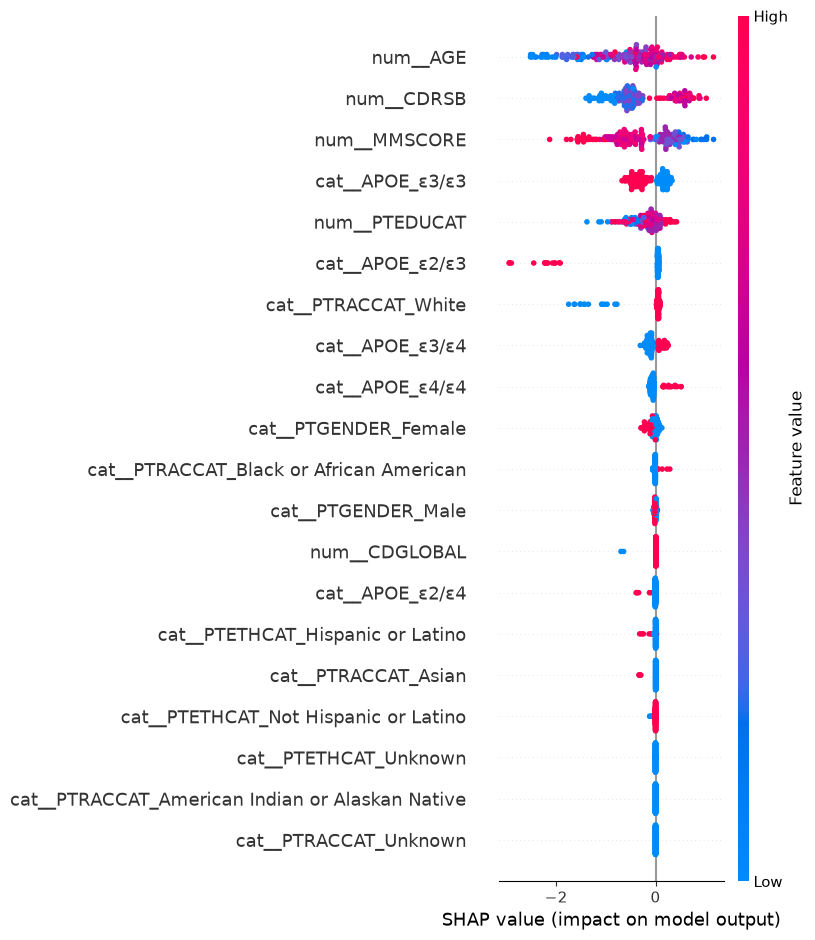

In [17]:
shap.summary_plot(
    xgb_shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [18]:
xgb_shap_df = pd.DataFrame(
    xgb_shap_values,
    columns=feature_names
)

xgb_shap_df.to_csv(
    "../results/xgboost_shap_values.csv",
    index=False
)

print("XGBoost SHAP values saved successfully.")
print("Saved shape:", xgb_shap_df.shape)

XGBoost SHAP values saved successfully.
Saved shape: (200, 22)


In [19]:
rf_explainer = shap.TreeExplainer(rf_model)

rf_shap_values = rf_explainer.shap_values(X_test_processed)

print("Random Forest SHAP values calculated successfully.")
print("SHAP type:", type(rf_shap_values))

if isinstance(rf_shap_values, list):
    print("Number of SHAP arrays:", len(rf_shap_values))
    for i, values in enumerate(rf_shap_values):
        print(f"Class {i} SHAP shape:", values.shape)
else:
    print("SHAP shape:", rf_shap_values.shape)

Random Forest SHAP values calculated successfully.
SHAP type: <class 'numpy.ndarray'>
SHAP shape: (200, 22, 2)


In [20]:
rf_shap_class1 = rf_shap_values[:, :, 1]

print("Random Forest class-1 SHAP values selected.")
print("SHAP shape:", rf_shap_class1.shape)

Random Forest class-1 SHAP values selected.
SHAP shape: (200, 22)


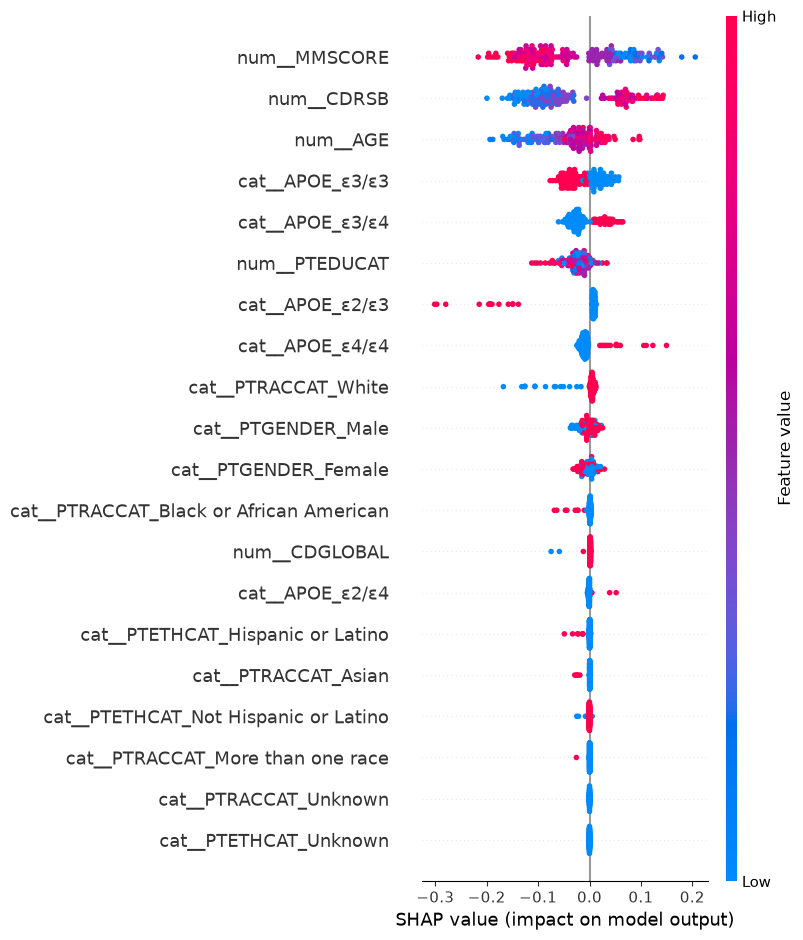

In [21]:
shap.summary_plot(
    rf_shap_class1,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [22]:
rf_shap_df = pd.DataFrame(
    rf_shap_class1,
    columns=feature_names
)

rf_shap_df.to_csv(
    "../results/random_forest_shap_values.csv",
    index=False
)

print("Random Forest SHAP values saved successfully.")
print("Saved shape:", rf_shap_df.shape)

Random Forest SHAP values saved successfully.
Saved shape: (200, 22)


In [23]:
ebm_global = ebm_model.explain_global()

print("EBM global explanation created successfully.")

EBM global explanation created successfully.


In [24]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(preprocessor, "../models/preprocessor.joblib")
joblib.dump(xgb_model, "../models/xgboost_model.joblib")
joblib.dump(rf_model, "../models/random_forest_model.joblib")
joblib.dump(ebm_model, "../models/ebm_model.joblib")

print("All models saved successfully.")

All models saved successfully.
